# 04 - Calibración, umbral y evaluación

Toma el modelo elegido en el notebook anterior (XGBoost optimizado) y lo
convierte en un sistema de decisión que maximiza la ganancia:

1. **Calibración** de las probabilidades del modelo.
2. **Umbral** que maximiza la ganancia (elegido en validación).
3. **Evaluación final** en test, comparada con baselines.

In [ ]:
import sys
sys.path.append("..")
%load_ext autoreload
%autoreload 2

# --- Librerías de terceros ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb_lib
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (brier_score_loss, average_precision_score,
                             precision_score, recall_score, f1_score)

# --- Código del proyecto (src/) ---
from src.data import load_raw, clean
from src.features import (temporal_split, build_preprocessor,
                          NUM_FEATURES, CAT_LOW, CAT_HIGH)
from src.model import build_xgb, BEST_XGB_PARAMS
from src import utils
from src.utils import PALETA
from src.profit import (find_best_threshold, profit_from_threshold,
                        BREAK_EVEN_THRESHOLD, total_profit, approve_all_profit,
                        reject_all_profit, max_possible_profit)

utils.set_style()
RANDOM_STATE = 42

# Cargar, limpiar y partir
df = clean(load_raw("../data/dataset.csv"))
train, val, test = temporal_split(df, train_frac=0.7, val_frac=0.15)

FEATURES = NUM_FEATURES + CAT_LOW + CAT_HIGH
X_train, y_train = train[FEATURES], train["fraude"]
X_val,   y_val   = val[FEATURES],   val["fraude"]
X_test,  y_test  = test[FEATURES],  test["fraude"]

spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = build_xgb(scale_pos_weight=spw, params=BEST_XGB_PARAMS)
xgb.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['b', 'c', 'd', 'e', 'f', 'h',
                                                   'l', 'm', 'monto',
                                                   'score']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imput',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=0.01,
                                                                                 sparse_output=False))]),
                                                  ['a', 'g', 'n', 'o', 'p']),...
                               feature_types=None, feature_weights=None,
                               gamma=0.926, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.0301, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=4,
                               max_leaves=None, min_child_weight=7, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=620, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Calibración de probabilidades

### Diagnóstico

El umbral de decisión económico (0,20) se aplica sobre las probabilidades del
modelo, así que estas tienen que ser **reales**: cuando el modelo dice 0,20,
debe haber ~20% de fraude. Pero XGBoost, al usar `scale_pos_weight` para
compensar el desbalance, produce probabilidades **sobreestimadas**. Calibrar corrige el *valor* de las probabilidades sin cambiar el ordenamiento
del modelo (qué casos son más riesgosos), por lo que el PR-AUC no se altera.

El *reliability diagram* compara la probabilidad predicha (eje X) con la
fracción real de fraude (eje Y). La calibración perfecta cae sobre la diagonal.

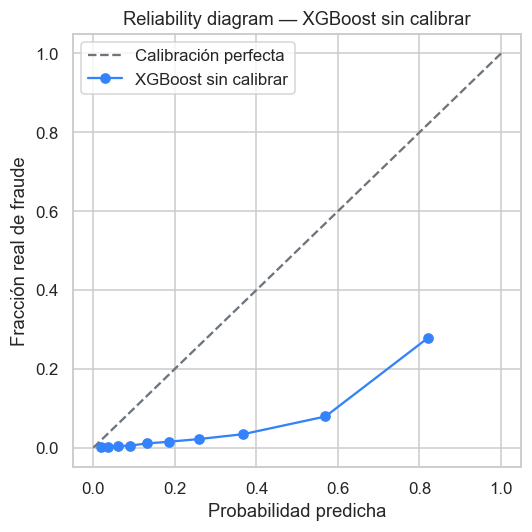

Brier score (sin calibrar): 0.1105


In [ ]:
p_val = xgb.predict_proba(X_val)[:, 1]
frac_real, prob_pred = calibration_curve(y_val, p_val, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color=PALETA["neutro"], label="Calibración perfecta")
ax.plot(prob_pred, frac_real, "o-", color=PALETA["principal"], label="XGBoost sin calibrar")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Fracción real de fraude")
ax.set_title("Reliability diagram — XGBoost sin calibrar")
ax.legend()
plt.tight_layout()
plt.show()

print("Brier score (sin calibrar):", round(brier_score_loss(y_val, p_val), 4))

La curva cae claramente **por debajo de la diagonal**: el modelo sobreestima el
fraude. El Brier score sin
calibrar es 0,11. 

### Calibración

Se aprende una **función correctora** que mapea el score
crudo del modelo a una probabilidad real. Se ajusta sobre validación, usando
los pares (score predicho, resultado real): aprende "cuando el modelo dice X,
la tasa real de fraude es Y". 

Se comparan dos métodos:

- **Sigmoid (Platt):** asume que la corrección tiene forma de curva S (dos
  parámetros). Simple y robusto con pocos datos, pero limitado a esa forma.
- **Isotonic:** ajusta una función escalonada **monótona no decreciente** (a
  mayor score, mayor o igual probabilidad, nunca menor). De forma libre, se
  adapta a distorsiones más complejas, pero necesita más datos.

Platt (estrictamente creciente) preserva exactamente el ranking, por lo que el
PR-AUC no cambia. Isotonic, en cambio, puede introducir empates que lo alteran
levemente.


In [ ]:
# Comparar los dos métodos en Brier (calibración) Y PR-AUC (ranking)
for metodo in ["sigmoid", "isotonic"]:
    cal = CalibratedClassifierCV(xgb, method=metodo, cv="prefit").fit(X_val, y_val)
    p = cal.predict_proba(X_val)[:, 1]
    print(f"{metodo:9} → Brier: {brier_score_loss(y_val, p):.4f} | "
          f"PR-AUC: {average_precision_score(y_val, p):.4f}")

print(f"{'sin cal.':9} → Brier: {brier_score_loss(y_val, p_val):.4f} | "
      f"PR-AUC: {average_precision_score(y_val, p_val):.4f}")

# Se elige Platt (sigmoid): preserva el ranking. 
xgb_cal = CalibratedClassifierCV(xgb, method="sigmoid", cv="prefit").fit(X_val, y_val)
p_val_cal = xgb_cal.predict_proba(X_val)[:, 1]

sigmoid   → Brier: 0.0339 | PR-AUC: 0.4426
isotonic  → Brier: 0.0321 | PR-AUC: 0.4300
sin cal.  → Brier: 0.1105 | PR-AUC: 0.4426


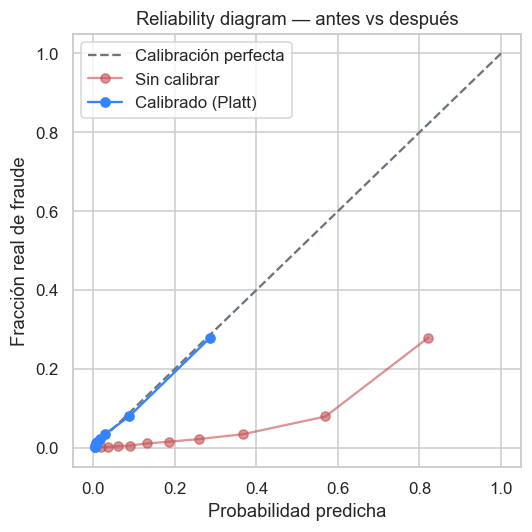

In [4]:
frac_c, prob_c = calibration_curve(y_val, p_val_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color=PALETA["neutro"], label="Calibración perfecta")
ax.plot(prob_pred, frac_real, "o-", color="#C44E52", alpha=0.6, label="Sin calibrar")
ax.plot(prob_c, frac_c, "o-", color=PALETA["principal"], label="Calibrado (Platt)")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Fracción real de fraude")
ax.set_title("Reliability diagram — antes vs después")
ax.legend()
plt.tight_layout()
plt.show()

Se comparan sigmoid (Platt) e isotonic en dos ejes: calidad de las
probabilidades (Brier) e impacto en el ranking (PR-AUC).

| Método | Brier (val) | PR-AUC (val) |
|--------|-------------|--------------|
| Sin calibrar | 0,110 | 0,442 |
| **Sigmoid (Platt)** | 0,034 | 0,442 |
| Isotonic | 0,032 | 0,433 |

Isotonic da un Brier levemente menor, pero **degrada el PR-AUC** (0,442 → 0,433):
al ser monótona no estrictamente creciente, genera empates que reducen el
Average Precision. Platt es estrictamente creciente, **preserva el ranking**
(0,442, idéntico al sin calibrar) y calibra con calidad equivalente. Como el
modelo se seleccionó por PR-AUC, se elige **Platt**.

## Umbral de ganancia

Con las probabilidades ya calibradas, se busca el umbral de decisión que
**maximiza la ganancia** sobre validación, usando la función de `profit.py`.
El umbral se elige en validación (nunca en test) para no sesgar la evaluación.

In [ ]:
monto_val = val["monto"].values

mejor_umbral, mejor_ganancia, grid, ganancias = find_best_threshold(
    y_val, monto_val, p_val_cal
)

print(f"Umbral óptimo (val): {mejor_umbral:.2f}")
print(f"Ganancia con umbral óptimo:  ${mejor_ganancia:,.0f}")
print(f"Ganancia con umbral 0.20:    "
      f"${profit_from_threshold(y_val, monto_val, p_val_cal, BREAK_EVEN_THRESHOLD):,.0f}")

Umbral óptimo (val): 0.25
Ganancia con umbral óptimo:  $171,391
Ganancia con umbral 0.20:    $168,273


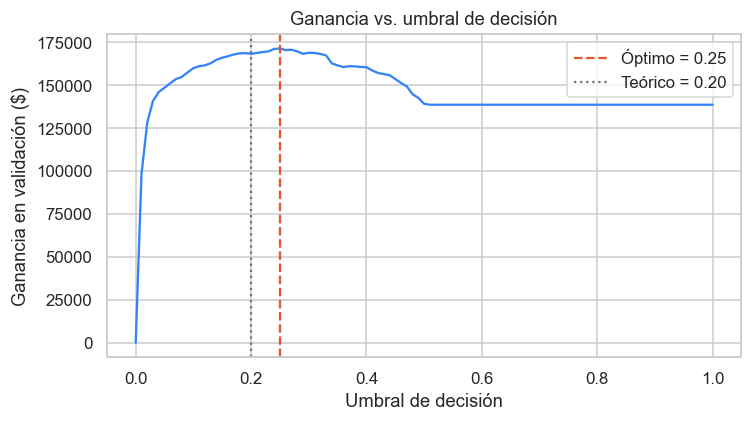

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, ganancias, color=PALETA["principal"])
ax.axvline(mejor_umbral, color=PALETA["acento"], ls="--", label=f"Óptimo = {mejor_umbral:.2f}")
ax.axvline(BREAK_EVEN_THRESHOLD, color=PALETA["neutro"], ls=":", label="Teórico = 0.20")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Ganancia en validación ($)")
ax.set_title("Ganancia vs. umbral de decisión")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluación

In [ ]:
monto_test = test["monto"].values
p_test_cal = xgb_cal.predict_proba(X_test)[:, 1]

# Decisión: aprobar si p <= umbral; rechazar (= predecir fraude) si p > umbral
aprobar = p_test_cal <= mejor_umbral
pred_fraude = ~aprobar

ganancia_modelo = total_profit(y_test, monto_test, aprobar)
maximo = max_possible_profit(y_test, monto_test)
aprobar_todo = approve_all_profit(y_test, monto_test)

print(f"=== Evaluación final en TEST (umbral {mejor_umbral:.2f}) ===")
print(f"Modelo:          ${ganancia_modelo:,.0f}")
print(f"Aprobar todo:    ${aprobar_todo:,.0f}")
print(f"Rechazar todo:   ${reject_all_profit(y_test, monto_test):,.0f}")
print(f"Máximo posible:  ${maximo:,.0f}")
print(f"\nCaptura {ganancia_modelo/maximo*100:.1f}% del máximo posible")
print(f"Mejora sobre 'aprobar todo': ${ganancia_modelo - aprobar_todo:,.0f}")

print(f"\n--- Clasificación en el umbral {mejor_umbral:.2f} ---")
print(f"Precision (fraude): {precision_score(y_test, pred_fraude):.3f}")
print(f"Recall (fraude):    {recall_score(y_test, pred_fraude):.3f}")
print(f"F1 (fraude):        {f1_score(y_test, pred_fraude):.3f}")

=== Evaluación final en TEST (umbral 0.25) ===
Modelo:          $172,219
Aprobar todo:    $138,456
Rechazar todo:   $0
Máximo posible:  $217,836

Captura 79.1% del máximo posible
Mejora sobre 'aprobar todo': $33,763

--- Clasificación en el umbral 0.25 ---
Precision (fraude): 0.395
Recall (fraude):    0.490
F1 (fraude):        0.437


### Baseline basado en el score provisto en el dataset.

In [ ]:
# Su umbral se optimiza en validación con la misma función de ganancia utilizada para seleccionar el umbral del modelo.
# Se asume que valores mayores de score representan mayor riesgo de fraude, según lo identificado en el análisis exploratorio.
score_val  = val["score"].values / 100    # score 0-100 → escala 0-1
score_test = test["score"].values / 100

umbral_score, _, _, _ = find_best_threshold(y_val, val["monto"].values, score_val)

# Se aprueban las transacciones cuyo riesgo estimado está por debajo o igual al umbral seleccionado.
aprobar_score = score_test <= umbral_score

ganancia_score = total_profit(y_test, monto_test, aprobar_score)

print(f"Score actual — umbral óptimo (val): {umbral_score:.2f}")
print(f"Score actual — ganancia (test):     ${ganancia_score:,.0f}")
print(f"Modelo — ganancia (test):           ${ganancia_modelo:,.0f}")
print(f"Mejora del modelo sobre el score:   ${ganancia_modelo - ganancia_score:,.0f}")

Score actual — umbral óptimo (val): 0.85
Score actual — ganancia (test):     $159,514
Modelo — ganancia (test):           $172,219
Mejora del modelo sobre el score:   $12,705


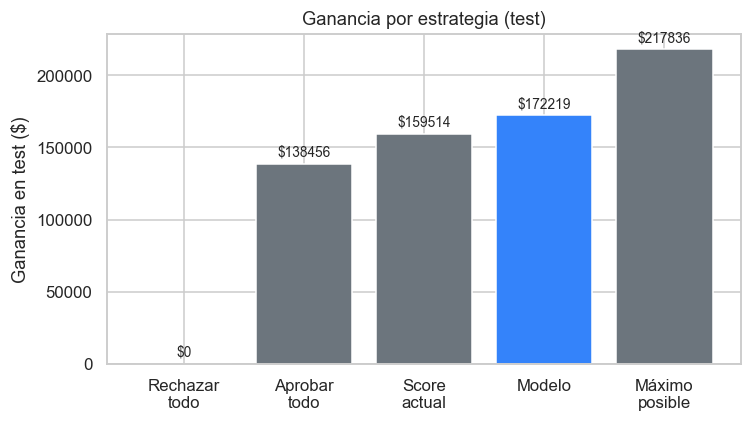

In [13]:
opciones = {
    "Rechazar\ntodo": reject_all_profit(y_test, monto_test),
    "Aprobar\ntodo": aprobar_todo,
    "Score\nactual": ganancia_score,
    "Modelo": ganancia_modelo,
    "Máximo\nposible": maximo,
}
nombres, valores = list(opciones), list(opciones.values())
colores = [PALETA["principal"] if n == "Modelo" else PALETA["neutro"] for n in nombres]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(nombres, valores, color=colores)
ax.bar_label(ax.containers[0], fmt="$%.0f", padding=3, fontsize=9)
ax.set_ylabel("Ganancia en test ($)")
ax.set_title("Ganancia por estrategia (test)")
plt.tight_layout()
plt.show()

### Evaluación final

Se aplica al test el umbral elegido en validación (0,25), sin re-optimizar.

| Estrategia | Ganancia (test) |
|------------|-----------------|
| Rechazar todo | $0 |
| Aprobar todo | $138.456 |
| Score actual (sistema preexistente) | $159.514 |
| **Modelo** | **$172.219** |
| Máximo posible | $217.836 |

El modelo captura el **79,1%** del máximo posible, supera a "aprobar todo" en
**$33.763** y al sistema de score existente en **~$12.700**. Se asume que
`score` está disponible antes de decidir (condición para usarlo como feature y
baseline).

Métricas en el umbral 0,25: precision 0,40, recall 0,49, F1 0,44. El recall
moderado es **intencional**: el objetivo es maximizar la ganancia, no la
detección — bajar el umbral atraparía más fraudes pero rechazaría más
legítimas, reduciendo la ganancia neta.

## Interpretabilidad (SHAP)

Se usa SHAP (TreeExplainer) para medir la contribución de cada variable a las
predicciones del modelo. 

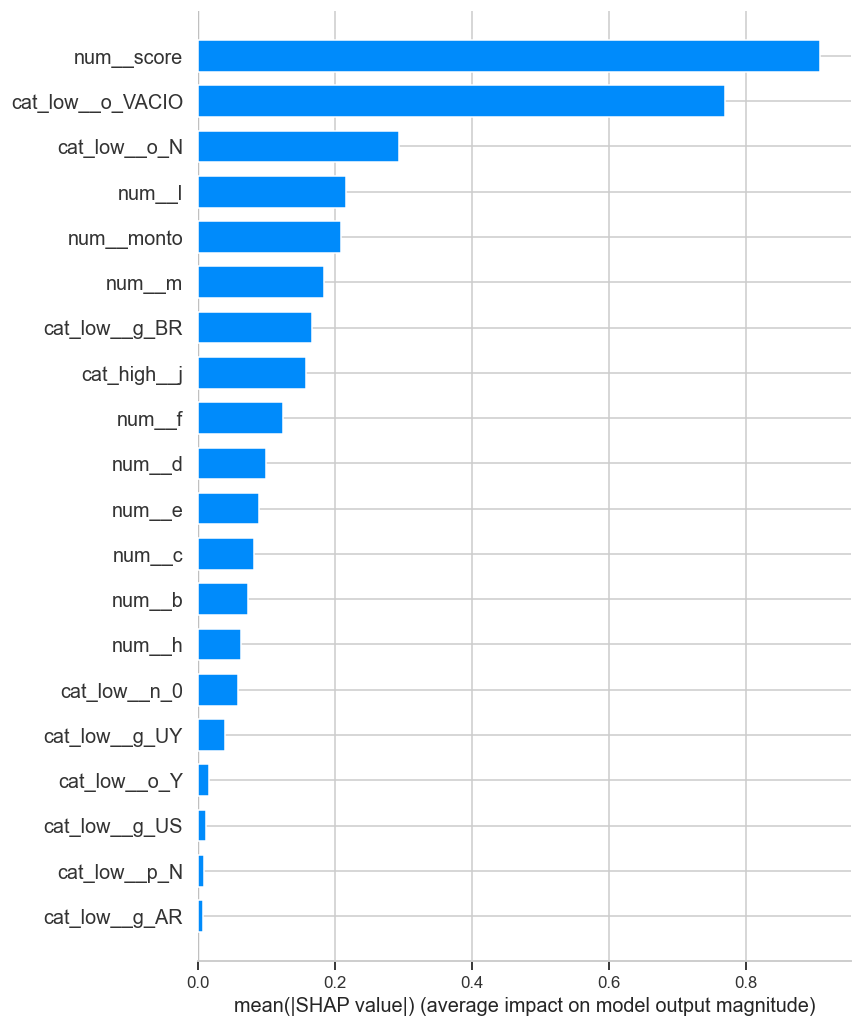

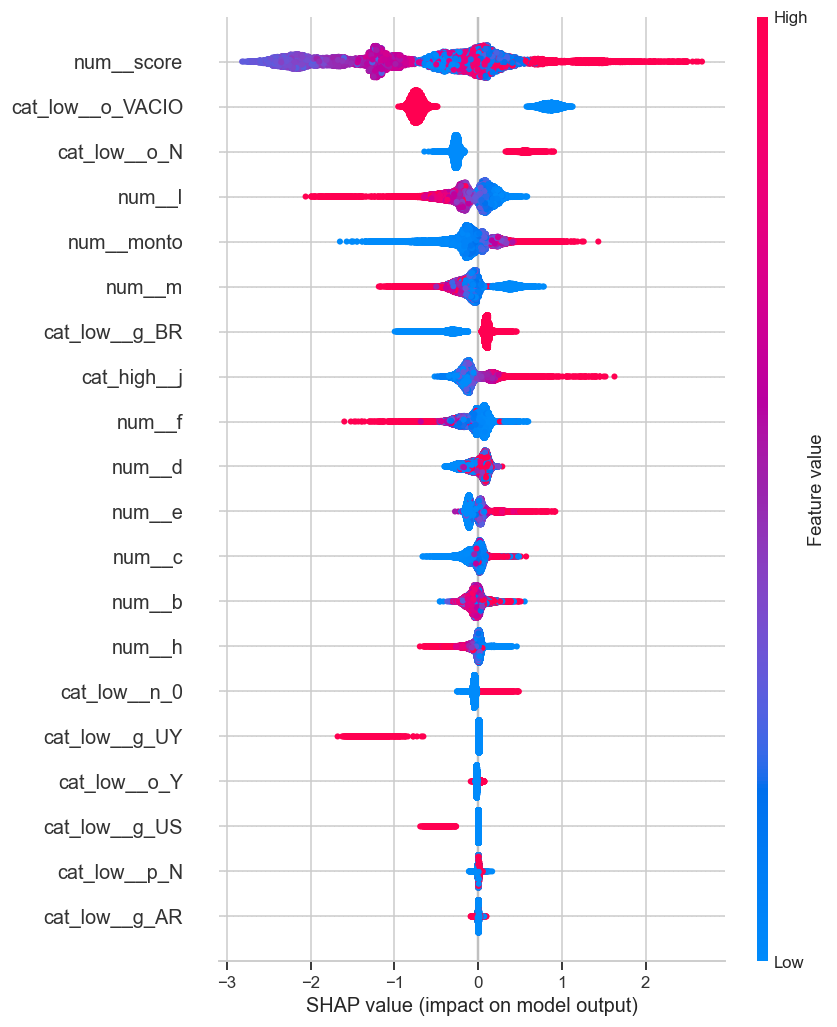

In [ ]:
pre = xgb.named_steps["pre"]
clf = xgb.named_steps["clf"]

X_val_p = pre.transform(X_val)
feat_names = pre.get_feature_names_out()

# SHAP nativo de XGBoost (evita el problema de versiones de shap)
dval = xgb_lib.DMatrix(X_val_p)
contribs = clf.get_booster().predict(dval, pred_contribs=True)
shap_values = contribs[:, :-1]   # la última columna es el sesgo (bias), la quitamos

# Graficamos con shap (solo usamos su función de dibujo, no su explainer)
shap.summary_plot(shap_values, X_val_p, feature_names=feat_names,
                  plot_type="bar", show=True)
shap.summary_plot(shap_values, X_val_p, feature_names=feat_names, show=True)

SHAP confirma y refuerza los hallazgos del EDA:

- **`score`** es la variable más importante; valores altos empujan hacia fraude
  (coherente con ser el score de riesgo del sistema actual).
- **`o`** es la segunda en importancia: `o=VACIO` empuja hacia legítima y `o=N`
  hacia fraude. Valida la decisión de tratar el vacío como categoría propia
  (de haberlo descartado, se habría perdido una de las señales más fuertes).
- **`monto`** alto empuja hacia fraude; **`l`, `m`, `f`** muestran señal inversa
  (valores altos → legítima), coherente con el análisis bivariado.
- **`j`** (target encoding) y el país (BR hacia fraude, UY/US hacia legítima)
  aportan señal consistente con las tasas observadas.

La coincidencia entre EDA, bivariado y SHAP da robustez al análisis: la misma
historia surge desde tres enfoques distintos.

### Ablation: Contribución de score

In [ ]:
# Modelo entrenado SIN la variable 'score'
num_sin = [c for c in NUM_FEATURES if c != "score"]
feat_sin = num_sin + CAT_LOW + CAT_HIGH

xgb_sin_score = Pipeline([
    ("pre", build_preprocessor(num=num_sin)),
    ("clf", XGBClassifier(**BEST_XGB_PARAMS, scale_pos_weight=spw,
                          eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(train[feat_sin], y_train)

pr_con = average_precision_score(y_val, xgb.predict_proba(X_val)[:, 1])
pr_sin = average_precision_score(y_val, xgb_sin_score.predict_proba(val[feat_sin])[:, 1])
print(f"PR-AUC con score: {pr_con:.3f}")
print(f"PR-AUC sin score: {pr_sin:.3f}")

PR-AUC con score: 0.443
PR-AUC sin score: 0.354


### Ablation: contribución de `score`

Se entrena el modelo sin la variable `score` para medir cuánta señal aporta:

| Modelo | PR-AUC (val) |
|--------|--------------|
| Con `score` | 0,44 |
| Sin `score` | 0,34 |

`score` aporta señal sustancial: sin él, la PR-AUC cae de 0,44 a 0,34. Es
coherente con SHAP, donde `score` es la variable más importante. Refuerza la
condición de que el score debe estar disponible antes de la decisión: si no lo
estuviera, el modelo perdería una fracción relevante de su capacidad predictiva.

### Baseline: el sistema de score actual

